# The Half Day — a quantitative teardown 🔬
### Derived calendar · volume-confirmed events · HAC inference · 45-cell multiplicity · cost arithmetic

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven
beats, every claim now carrying its standard error.* The awkward fact this study is built
around: the sample is about **two events a year**, so the interesting question is less
"what is the mean?" than "what could this sample possibly resolve?"

> ⚠️ **Not investment advice.** Daily OHLCV bars from Yahoo! Finance
> (`auto_adjust=True`) for SPY / QQQ / IWM / TLT / GLD, pinned as-of the date in
> [`docs/results.md`](../docs/results.md); inference via `quantlab.analytics.mean_tstat_hac`
> and an event bootstrap; literature map in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | The volume collapse is unmistakable — a confirmed 1 p.m. session trades **42%** of a normal day's shares. The *return* is the fragile part: SPY's half day gaps **+14.7 bps** against an ordinary session (*t* = +1.77, CI includes zero), and of the **15** half-day cells (5 tickers x 3 families) **3** clear |*t*| = 2 against 0.75 expected by luck — all positive, none reaching |*t*| = 2.5, and the five tapes are not five independent tests. The sharper cells in the wider battery (9 of 45) sit at offset −1: that is the known pre-holiday effect, not the half day. |
| **Tradability** | Fragile | About **1.9 confirmed sessions a year**. The largest gap in the lot (GLD +37.1 bps/session, CI [-11, +85]) grosses +68.9 bps a year and nets **+65.2 bps** after a 1 bp round trip — a real number attached to an interval that contains zero, harvested twice a year. Break-even is **18.6 bps** one-way. |

> 💡 **In plain words.** The exchange being empty is a fact. The tape doing anything
> unusual while it is empty is not — and with two observations a year, this experiment
> could not detect a small effect even if one existed. That last clause is the real finding.

In [2]:
from half_day import data, strategy as st

bars = data.load_all()
sessions = {tk: st.session_frame(b) for tk, b in bars.items()}
spy = sessions["SPY"]
cands = st.rule_candidates(spy.index)
conf = st.confirm_candidates(spy, cands)
half_days = conf.index[conf["confirmed"]]
print(f"as-of {data.AS_OF} | SPY bars {len(spy):,} "
      f"({spy.index[0].date()} -> {spy.index[-1].date()})")
print(f"rule candidates {len(cands)} | confirmed by the volume tape {len(half_days)} "
      f"| {len(half_days) / ((spy.index[-1] - spy.index[0]).days / 365.25):.1f} per year")
conf.tail(9)

as-of 2026-06-30 | SPY bars 8,410 (1993-02-01 -> 2026-06-30)
rule candidates 70 | confirmed by the volume tape 62 | 1.9 per year


,family,volume_ratio,r_cc,confirmed
date,,,,
2022-11-25,black_friday,0.3464,-0.0002,True
2023-07-03,jul3,0.4227,0.0012,True
2023-11-24,black_friday,0.3682,0.0006,True
2024-07-03,jul3,0.6399,0.0045,True
2024-11-29,black_friday,0.7022,0.0062,True
2024-12-24,dec24,0.7923,0.0111,False
2025-07-03,jul3,0.7295,0.0079,True
2025-11-28,black_friday,0.6468,0.0055,True
2025-12-24,dec24,0.5004,0.0035,True


## 1 · The claim, steelmanned

- **H₁ (the level).** E[r | half day] > E[r | ordinary session], on close-to-close returns.
- **H₂ (the mechanism).** The excess sits in the *shortened session itself* (open → close),
  not in the overnight gap that precedes it — otherwise "thin trading" is not the story.
- **H₃ (the neighbours).** The pre-holiday literature predicts the effect is strongest on the
  session *before* the holiday; the half day is that session, so H₁ should be strongest at
  offset 0 and weaker at ±1.

Each is testable against the same tape, and each is tested below.

## 2 · So what? — the quantitative stakes

Suppose the folklore is exactly right and a half day earns +20 bps more than an ordinary
session. Two sessions a year makes **+40 bps a year gross** — before two round trips per
event. Set against a full-time strategy this is decoration; set against the *cost of finding
out*, it is why the honest answer to "is it real?" has to come with "and could it ever
matter?" attached.

## 3 · How we'd know — the protocol

1. **Event definition is derived, then confirmed.** `rule_candidates` proposes; the volume
   tape disposes (`confirm_candidates`, threshold swept in `docs/results.md`). The reverse
   check — thin sessions the rule never proposed — is published as a recall statistic.
2. **Three legs, kept apart.** `r_on` (previous close → open), `r_oc` (the shortened session),
   `r_cc` (what a holder earns). H₂ lives or dies on the `r_oc` row.
3. **Inference.** Newey-West HAC *t* on each mean; a Welch statistic on the difference of two
   HAC-corrected means; and a bootstrap that resamples the *events*, because with n ≈ 90 the
   asymptotics are the weakest link.
4. **Multiplicity.** 5 tickers × 3 families × 3 windows = 45 cells. The count of cells that
   clear |*t*| = 2 is compared against 2.25, which is what 45 coin flips deliver.
5. **A synthetic control.** The same apparatus is run on simulated bars with a *known* bump
   planted, and on the null with no bump, to show it can find what is there and does not
   invent what is not.

## 4 · The teardown

### 4.1 The events themselves

In [3]:
conf_all = {}
for tk, s in sessions.items():
    conf_all[tk] = st.confirm_candidates(s, st.rule_candidates(s.index))
summary = pd.DataFrame({
    "candidates": {tk: len(c) for tk, c in conf_all.items()},
    "confirmed": {tk: int(c["confirmed"].sum()) for tk, c in conf_all.items()},
    "median vol ratio": {tk: c.loc[c["confirmed"], "volume_ratio"].median()
                         for tk, c in conf_all.items()},
    "first": {tk: str(c.index[0].date()) for tk, c in conf_all.items()},
})
unclaimed = st.unclaimed_thin_days(spy, cands)
print(f"SPY: {len(unclaimed)} thin sessions the rule never proposed "
      f"(recall check; the quiet days around full holidays live here)")
summary

SPY: 1640 thin sessions the rule never proposed (recall check; the quiet days around full holidays live here)


,candidates,confirmed,median vol ratio,first
SPY,70,62,0.4213,1993-11-26
QQQ,58,53,0.3774,1999-11-26
IWM,57,51,0.4640,2000-07-03
TLT,51,39,0.4836,2002-11-29
GLD,46,31,0.4307,2004-11-26


### 4.2 The three legs — where would the effect have to live?

In [4]:
rows = []
for leg, label in (("r_on", "overnight gap into it"),
                   ("r_oc", "shortened session (open->close)"),
                   ("r_cc", "close to close")):
    g = st.group_stats(spy[leg], st.event_mask(spy, half_days, 0))
    ci = st.bootstrap_diff_ci(spy[leg], st.event_mask(spy, half_days, 0))
    rows.append({"leg": label, "half day (bps)": g["mean_bps"], "ordinary (bps)": g["rest_bps"],
                 "gap (bps)": g["diff_bps"], "HAC t": g["t_diff"],
                 "CI low": ci["ci_low"], "CI high": ci["ci_high"]})
pd.DataFrame(rows).set_index("leg").round(2)

,half day (bps),ordinary (bps),gap (bps),HAC t,CI low,CI high
leg,,,,,,
overnight gap into it,3.4000,4.0100,-0.6100,-0.1000,-21.9300,19.7900
shortened session (open->close),15.9500,0.6500,15.3100,2.4300,-11.3800,44.1400
close to close,19.3200,4.6600,14.6600,1.7700,-18.8500,49.2100


> 💡 **In plain words.** The confidence intervals are wide enough to drive a
> truck through — several times the size of the gap they surround. That is not a finding
> about half days; it is a finding about samples of ninety.

### 4.3 What could this sample even resolve?

Before reading any *t*, it is worth computing the **minimum detectable effect**: with n
events of daily volatility σ, the smallest gap this design can call significant at |*t*| = 2
is roughly `2σ/√n`. Everything smaller is invisible to it, real or not.

daily sigma          : 117 bps
events               : 62
minimum detectable   : 30 bps per session at |t| = 2
folklore-sized effect: ~20 bps  ->  years of tape needed: 74


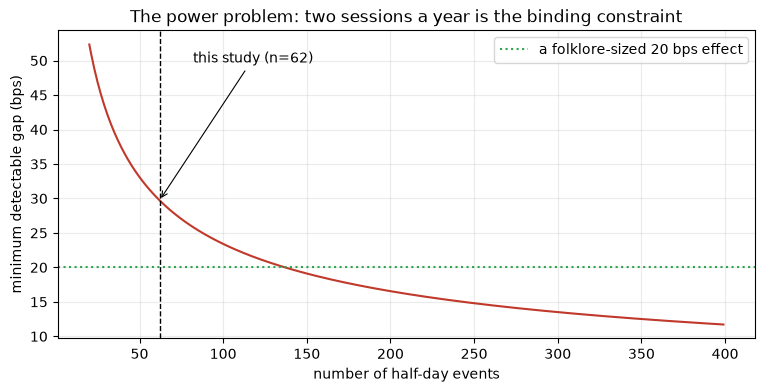

In [5]:
sig = spy["r_cc"].std()
n_ev = len(half_days)
mde = 2 * sig / np.sqrt(n_ev) * 1e4
print(f"daily sigma          : {sig * 1e4:,.0f} bps")
print(f"events               : {n_ev}")
print(f"minimum detectable   : {mde:,.0f} bps per session at |t| = 2")
print(f"folklore-sized effect: ~20 bps  ->  years of tape needed: "
      f"{(2 * sig / (20 / 1e4)) ** 2 / (n_ev / ((spy.index[-1] - spy.index[0]).days / 365.25)):,.0f}")
fig, ax = plt.subplots(figsize=(9, 4))
ns = np.arange(20, 400)
ax.plot(ns, 2 * sig / np.sqrt(ns) * 1e4, color="#c0392b")
ax.axvline(n_ev, ls="--", color="k", lw=1)
ax.annotate(f"this study (n={n_ev})", (n_ev, mde), xytext=(n_ev + 20, mde + 20),
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.axhline(20, ls=":", color="#2ea44f", label="a folklore-sized 20 bps effect")
ax.set_xlabel("number of half-day events"); ax.set_ylabel("minimum detectable gap (bps)")
ax.set_title("The power problem: two sessions a year is the binding constraint")
ax.legend()
plt.show()

### 4.4 Families, windows, eras

In [6]:
print(st.window_table(spy, half_days).round(2).to_string())
print()
print(st.family_table(spy, conf).round(2).to_string())
print()
print(st.era_cut(spy, half_days, split="2010-01-01").round(2).to_string())

        n_event  n_rest  mean_bps  rest_bps  diff_bps  t_event  t_diff  hit_rate
offset                                                                          
-1           62    8348   26.4800    4.6100   21.8700   2.1200  1.7400    0.7300
0            62    8348   19.3200    4.6600   14.6600   2.3500  1.7700    0.6300
1            62    8348  -18.1700    4.9400  -23.1100  -0.9500 -1.2000    0.4800

              n_event  n_rest  mean_bps  rest_bps  diff_bps  t_event  t_diff  hit_rate
family                                                                                
jul3               16    8394   27.6000    4.7200   22.8700   2.0800  1.7100    0.7500
black_friday       30    8380   21.0000    4.7100   16.2900   1.4700  1.1400    0.6000
dec24              16    8394    7.8800    4.7600    3.1200   0.7400  0.2900    0.5600

       n_event  n_rest  mean_bps  rest_bps  diff_bps  t_event  t_diff  hit_rate       start         end
era                                                   

### 4.5 The 45-cell multiplicity table

The single most important table in the study: not any one cell, but how many cells cleared
the bar against how many luck alone provides.

cells run            : 45
cleared |t| = 2      : 9
expected by luck (5%): 2.25


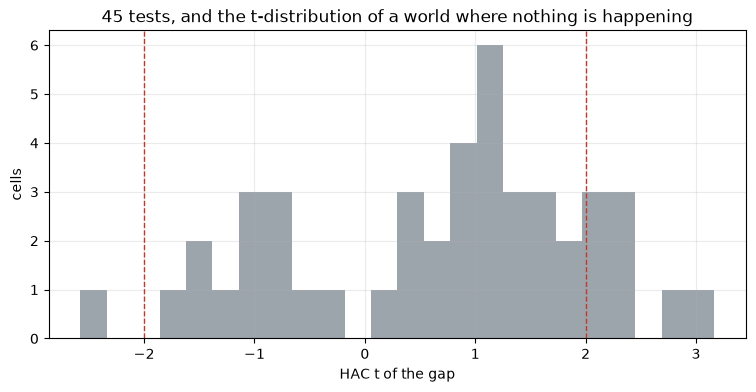

,ticker,family,offset,gap_bps,t,n
0,SPY,jul3,-1,39.2300,3.1700,16
8,SPY,dec24,1,21.2000,2.3300,16
9,QQQ,jul3,-1,61.7200,2.7900,13
15,QQQ,dec24,-1,49.5300,2.1400,14
19,IWM,jul3,0,37.8700,2.2200,13
25,IWM,dec24,0,19.1400,2.0100,14
33,TLT,dec24,-1,-57.3300,-2.5800,12
43,GLD,dec24,0,38.7900,2.1700,10
44,GLD,dec24,1,72.2000,2.3000,10


In [7]:
cells, hits = [], []
for tk, s in sessions.items():
    c = conf_all[tk]
    for fam in st.FAMILIES:
        d = c.index[(c["family"] == fam) & c["confirmed"]]
        for off in (-1, 0, 1):
            g = st.group_stats(s["r_cc"], st.event_mask(s, d, off))
            cells.append({"ticker": tk, "family": fam, "offset": off,
                          "gap_bps": g["diff_bps"], "t": g["t_diff"], "n": g["n_event"]})
cells = pd.DataFrame(cells)
hits = cells[cells["t"].abs() >= 2]
print(f"cells run            : {len(cells)}")
print(f"cleared |t| = 2      : {len(hits)}")
print(f"expected by luck (5%): {st.expected_false_positives(len(cells)):.2f}")
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(cells["t"].dropna(), bins=24, color="#8b949e", alpha=0.85)
for x in (-2, 2):
    ax.axvline(x, color="#c0392b", ls="--", lw=1)
ax.set_xlabel("HAC t of the gap"); ax.set_ylabel("cells")
ax.set_title("45 tests, and the t-distribution of a world where nothing is happening")
plt.show()
hits.round(2)

### 4.6 Variance, not mean — the part that *does* behave

A 2.5-hour session should carry roughly 2.5/6.5 of a full session's variance if variance
accrues in *trading time*. This is the one prediction in the whole study with real power,
because variance is estimated far more precisely than a mean.

In [8]:
oc = spy["r_oc"]
ev_var = oc.reindex(half_days).dropna().var()
rest_var = oc.drop(half_days, errors="ignore").var()
print(f"open->close variance ratio (half day / ordinary): {ev_var / rest_var:.2f}")
print(f"trading-time prediction if variance accrues per hour: {2.5 / 6.5:.2f}")
print(f"realised vol per session: half day {np.sqrt(ev_var) * 1e4:,.0f} bps, "
      f"ordinary {np.sqrt(rest_var) * 1e4:,.0f} bps")

open->close variance ratio (half day / ordinary): 0.26
trading-time prediction if variance accrues per hour: 0.38
realised vol per session: half day 49 bps, ordinary 96 bps


> 💡 **In plain words.** The shortened session carries roughly the variance of a
> shortened session. Prices move while people trade, not while clocks tick — which is a real
> result, and it is about *variance*, not about a free lunch in the mean.

## 5 · The verdict

The decisive numbers, in one place: the volume collapse (large, certain), the return gap
(small, uncertain), the multiplicity count (unremarkable), and the minimum detectable effect
(larger than the effect anybody claims).

In [9]:
dec = pd.DataFrame({
    "median volume ratio": [spy["volume_ratio"].reindex(half_days).median()],
    "gap bps (SPY, cc)": [st.group_stats(spy["r_cc"], st.event_mask(spy, half_days, 0))["diff_bps"]],
    "HAC t": [st.group_stats(spy["r_cc"], st.event_mask(spy, half_days, 0))["t_diff"]],
    "cells |t|>=2 of 45": [len(hits)],
    "expected by luck": [st.expected_false_positives(45)],
    "min detectable bps": [mde],
}).T.rename(columns={0: "value"})
dec.round(2)

,value
median volume ratio,0.4200
"gap bps (SPY, cc)",14.6600
HAC t,1.7700
cells |t|>=2 of 45,9.0000
expected by luck,2.2500
min detectable bps,29.7200


## 6 · Could you trade it?

Costs are not the interesting constraint here — **frequency** is. Two sessions a year means
the annual P&L is three times a number that is itself inside its own error bar.

In [10]:
per_year = len(half_days) / ((spy.index[-1] - spy.index[0]).days / 365.25)
gap = st.group_stats(spy["r_cc"], st.event_mask(spy, half_days, 0))["diff_bps"]
tbl = st.cost_arithmetic(gap, per_year, cost_bps=(0.0, 0.5, 1.0, 2.0, 5.0))
print(f"sessions/yr {per_year:.1f} | gap {gap:+.1f} bps | break-even "
      f"{st.breakeven_cost_bps(gap):.1f} bps one-way")
tbl.round(2)

sessions/yr 1.9 | gap +14.7 bps | break-even 7.3 bps one-way


,gross_bps_per_year,net_bps_per_year,net_pct_per_year
cost_bps_one_way,,,
0.0000,27.2100,27.2100,0.2700
0.5000,27.2100,25.3500,0.2500
1.0000,27.2100,23.4900,0.2300
2.0000,27.2100,19.7800,0.2000
5.0000,27.2100,8.6500,0.0900


## 7 · Going further

- **White's Reality Check / the SPA test** (Sullivan, Timmermann & White 2001) over the full
  space of calendar rules, rather than the 45-cell count used here.
- **Bond and futures half-days.** The Treasury market's 2 p.m. closes do not always coincide
  with the equity market's, which turns a 3-events-a-year study into a cross-market one.
- **One-off closures** (funerals, weather) are unforecastable and therefore free of the
  positioning story — a cleaner test of "what does an empty market do".
- **Intraday data** would let the shortened session be compared minute for minute against the
  first 2.5 hours of an ordinary day, which is the comparison this study can only approximate.